In [28]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler , LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score , confusion_matrix , accuracy_score , precision_score , recall_score

In [29]:
df = pd.read_csv("D:/College Practicals/DSBDA Practical Final/Social_Network_Ads.csv")

In [30]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [31]:
df.tail()

,User ID,Gender,Age,EstimatedSalary,Purchased
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0
399,15594041,Female,49,36000,1


In [32]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [33]:
df.shape

(400, 5)

In [34]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [35]:
# Encoding (Gender)
le = LabelEncoder()
df['Gender'] = le.fit_transform( df['Gender'])

In [36]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,1,19,19000,0
1,15810944,1,35,20000,0
2,15668575,0,26,43000,0
3,15603246,0,27,57000,0
4,15804002,1,19,76000,0


In [37]:
X = df.drop('Purchased', axis=1)
y = df['Purchased']

In [38]:
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.3,random_state=0)

In [39]:
sc = MinMaxScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [40]:
model = LogisticRegression()
model.fit(X_train , y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [41]:
y_pred = model.predict(X_test)

In [42]:
cm = confusion_matrix( y_test , y_pred )
cm

array([[76,  3],
       [15, 26]])

In [43]:
print(cm)

[[76  3]
 [15 26]]


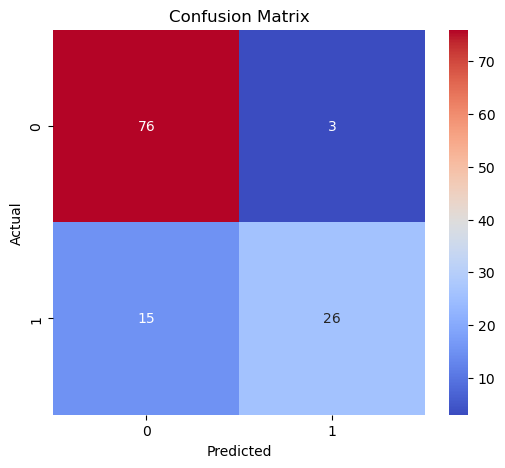

In [45]:
plt.figure(figsize=(6,5))
sns.heatmap( cm , annot=True , fmt='d', cmap='coolwarm')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [46]:
TN , FP , FN , TP = cm.ravel()

In [48]:
a = ( TP + TN ) / ( TP + FP + TN + FN )
a

np.float64(0.85)

In [50]:
error = 1-a
error

np.float64(0.15000000000000002)

In [51]:
p = TP / ( TP + FP )
p

np.float64(0.896551724137931)

In [52]:
r = TP / ( TP + FN )
r

np.float64(0.6341463414634146)

In [53]:
f = (2*r*p) / (p+r)
f

np.float64(0.7428571428571429)

In [54]:
accuracy = accuracy_score(y_test , y_pred)
print(accuracy)
error = 1 - accuracy
print(error)
precision = precision_score(y_test, y_pred)
print(precision)
recall = recall_score(y_test,y_pred)
print(recall)

0.85
0.15000000000000002
0.896551724137931
0.6341463414634146
